# Model Comparison — VIX

7-model comparison: MLP, MLP-log, MLP-log-arb, Conv, Conv-log, Conv-log-arb, Heston  
**Prerequisites:** `python scripts/run_pipeline.py --ticker VIX --stages eval heston compare`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path
from collections import OrderedDict

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 6)

TICKER = "VIX"
ROOT = Path("../../..")
EVAL_DIR = ROOT / "artifacts" / "eval" / TICKER
HESTON_DIR = ROOT / "data" / "processed" / "heston" / "surfaces"
OUT = ROOT / "artifacts" / "comparison" / TICKER
OUT.mkdir(parents=True, exist_ok=True)
(OUT / "plots").mkdir(exist_ok=True)
(OUT / "tables").mkdir(exist_ok=True)

VARIANTS = OrderedDict([
    ("MLP",          "mlp"),
    ("MLP-log",      "mlp_log"),
    ("MLP-log-arb",  "mlp_log_arb"),
    ("Conv",         "conv"),
    ("Conv-log",     "conv_log"),
    ("Conv-log-arb", "conv_log_arb"),
])

COLOURS = {
    "MLP": "#1f77b4", "MLP-log": "#9467bd", "MLP-log-arb": "#d62728",
    "Conv": "#2ca02c", "Conv-log": "#8c564b", "Conv-log-arb": "#e377c2",
    "Heston": "#ff7f0e",
}

print(f"Ticker: {TICKER}")
print(f"Eval dir: {EVAL_DIR.resolve()}")

Ticker: VIX
Eval dir: C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\eval\VIX


## §1 Load & Align Surfaces

In [2]:
# Load all VAE surfaces
vae_surfs = {}
grid_spec = None
for label, variant in VARIANTS.items():
    sdir = EVAL_DIR / variant / "surfaces"
    if not sdir.exists():
        print(f"⚠  {label}: not found ({sdir})")
        continue
    model_s = np.load(sdir / "vae_surfaces.npy")
    market_s = np.load(sdir / "market_surfaces.npy")
    dates_s = pd.to_datetime(pd.read_csv(sdir / "vae_surface_dates.csv")["date"])
    vae_surfs[label] = (model_s, market_s, dates_s)
    if grid_spec is None:
        with open(sdir / "grid_spec.json") as f:
            grid_spec = json.load(f)
    print(f"✓ {label:<14} {model_s.shape}  ({len(dates_s)} dates)")

# Load Heston
heston_path = HESTON_DIR / f"{TICKER}_heston_surfaces.npy"
heston_dates_path = HESTON_DIR / f"{TICKER}_heston_surface_dates.csv"
has_heston = heston_path.exists()
if has_heston:
    heston_surf = np.load(heston_path)
    heston_dates = pd.to_datetime(pd.read_csv(heston_dates_path)["date"])
    print(f"✓ {'Heston':<14} {heston_surf.shape}  ({len(heston_dates)} dates)")
else:
    print("⚠ Heston not found — VAE-only comparison")

days_grid = np.array(grid_spec["days_grid"])
delta_grid = np.array(grid_spec["delta_grid"])
cp_labels = grid_spec["cp_order"]
n_chan, n_mat, n_del = len(cp_labels), len(days_grid), len(delta_grid)
print(f"\nGrid: {cp_labels} × {n_mat} maturities × {n_del} deltas")

✓ MLP            (244, 2, 11, 17)  (244 dates)
✓ MLP-log        (244, 2, 11, 17)  (244 dates)
✓ MLP-log-arb    (244, 2, 11, 17)  (244 dates)
✓ Conv           (244, 2, 11, 17)  (244 dates)
✓ Conv-log       (244, 2, 11, 17)  (244 dates)
✓ Conv-log-arb   (244, 2, 11, 17)  (244 dates)
✓ Heston         (244, 2, 11, 17)  (244 dates)

Grid: ['C', 'P'] × 11 maturities × 17 deltas


In [3]:
# Align to common dates
def _ds(dates): return set(dates.dt.date)

first_name = next(iter(vae_surfs))
common = _ds(vae_surfs[first_name][2])
for name, (_, _, dates) in vae_surfs.items():
    common &= _ds(dates)
if has_heston:
    common &= _ds(heston_dates)
common = sorted(common)
N = len(common)

models = OrderedDict()
for name, (surf, _, dates) in vae_surfs.items():
    mask = [d in common for d in dates.dt.date]
    models[name] = surf[mask]

if has_heston:
    hmask = [d in common for d in heston_dates.dt.date]
    models["Heston"] = heston_surf[hmask]

first_vae = next(iter(vae_surfs.values()))
market_mask = [d in common for d in first_vae[2].dt.date]
market = first_vae[1][market_mask]
aligned_dates = first_vae[2][market_mask].reset_index(drop=True)

MODEL_NAMES = list(models.keys())

valid = np.isfinite(market)
for surf in models.values():
    valid &= np.isfinite(surf)

print(f"Common dates: {N},  Valid cells: {valid.sum():,}/{valid.size:,} ({100*valid.sum()/valid.size:.1f}%)")

Common dates: 244,  Valid cells: 90,782/91,256 (99.5%)


## §2 Summary Metrics

In [4]:
rows = []
for name, surf in models.items():
    e = (surf - market)[valid]
    ae = np.abs(e)
    rows.append({
        "Model": name,
        "MAE (vp)": ae.mean()*100,
        "RMSE (vp)": np.sqrt((e**2).mean())*100,
        "Max Error (vp)": ae.max()*100,
        "Median AE (vp)": np.median(ae)*100,
        "P95 (vp)": np.percentile(ae, 95)*100,
        "P99 (vp)": np.percentile(ae, 99)*100,
    })

summary = pd.DataFrame(rows).set_index("Model").sort_values("MAE (vp)")
summary.to_csv(OUT / "tables" / "summary_metrics.csv")
print(f"{TICKER} — Summary Metrics (vol points):")
display(summary.round(3))

VIX — Summary Metrics (vol points):


,MAE (vp),RMSE (vp),Max Error (vp),Median AE (vp),P95 (vp),P99 (vp)
Model,,,,,,
MLP,7.103,12.564000,191.753998,4.543,21.351999,52.973999
Conv,7.457,12.914000,179.253998,4.811,22.416000,53.541000
MLP-log,7.833,16.601999,344.753998,4.175,24.823000,77.700996
Conv-log-arb,8.085,17.837999,384.768005,4.278,24.920000,82.294998
Conv-log,8.146,17.818001,392.838989,4.069,26.733999,81.915001
MLP-log-arb,10.495,22.846001,478.015015,5.483,34.388000,104.195999
Heston,13.340,26.725000,497.622986,6.832,43.979000,117.612999


## §3 Error Heatmaps (per-cell MAE)

C:\Users\Admin\AppData\Local\Temp\ipykernel_32600\1835182442.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


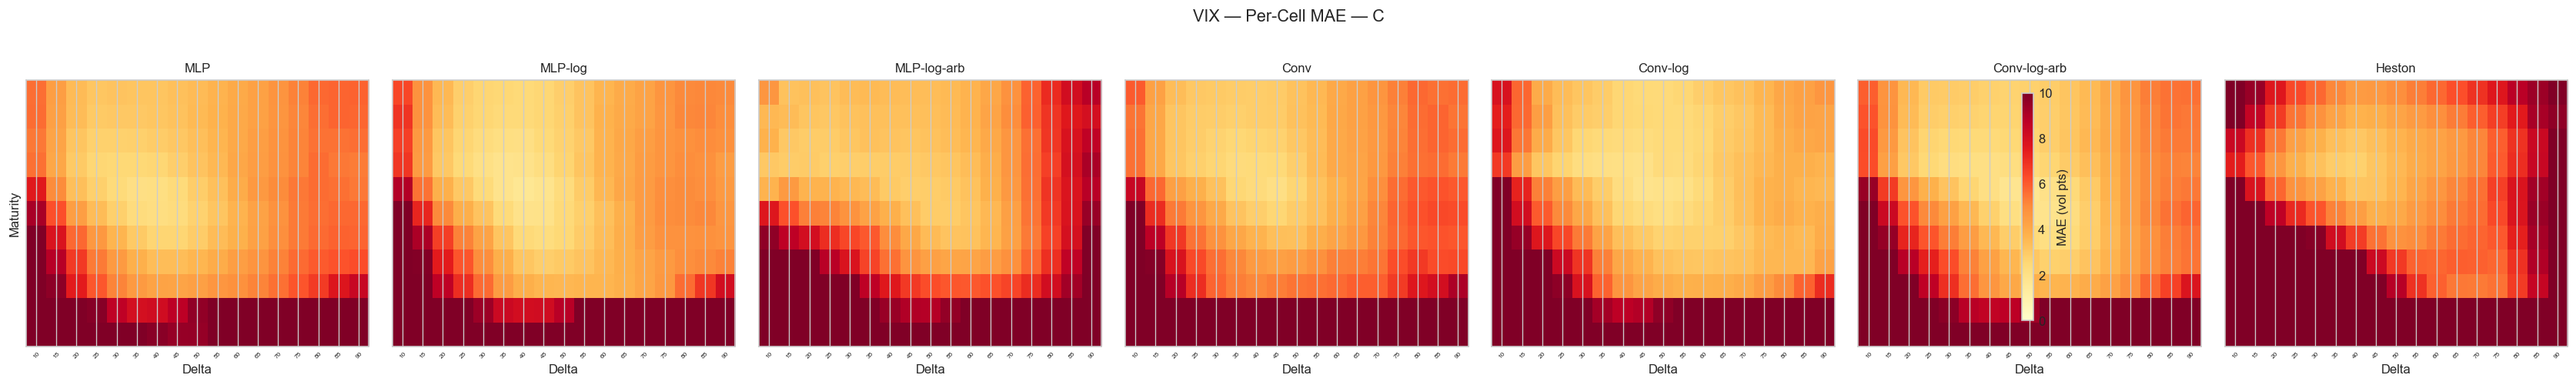

C:\Users\Admin\AppData\Local\Temp\ipykernel_32600\1835182442.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


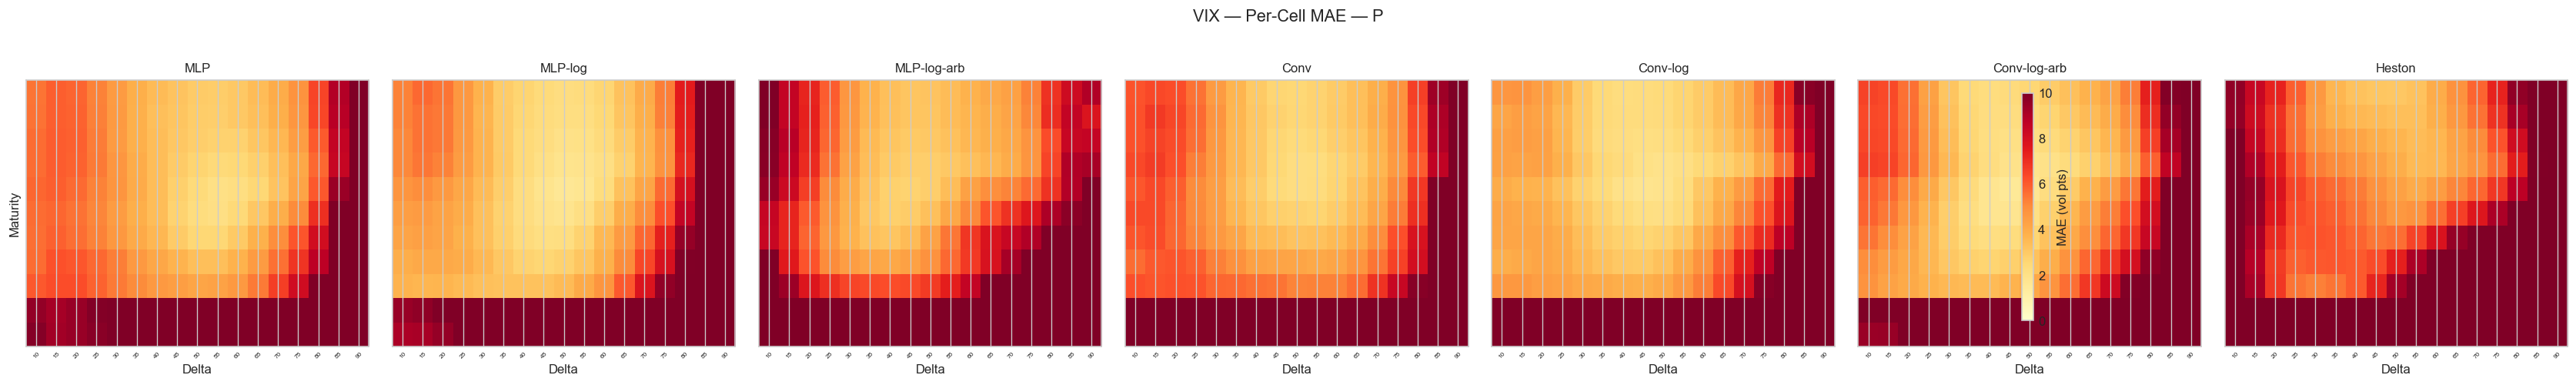

In [5]:
delta_labels = [f"{d:.0f}" for d in delta_grid * 100]
mat_labels = [f"{d:.0f}d" for d in days_grid]

for ch_idx, ch_name in enumerate(cp_labels):
    fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(4*len(MODEL_NAMES), 4), sharey=True)
    if len(MODEL_NAMES) == 1: axes = [axes]
    vmax = 0
    mae_grids = {}
    for name in MODEL_NAMES:
        err = np.abs(models[name][:, ch_idx] - market[:, ch_idx])
        vm = valid[:, ch_idx]
        with np.errstate(invalid="ignore"):
            mg = np.where(vm, err, np.nan)
            mae_grids[name] = np.nanmean(mg, axis=0) * 100
        vmax = max(vmax, np.nanmax(mae_grids[name]))

    for ax, name in zip(axes, MODEL_NAMES):
        im = ax.imshow(mae_grids[name], cmap="YlOrRd", vmin=0, vmax=min(vmax, 10),
                       aspect="auto", origin="lower")
        ax.set_title(name, fontsize=10)
        ax.set_xticks(range(n_del))
        ax.set_xticklabels(delta_labels, fontsize=5, rotation=45)
        ax.set_xlabel("Delta")
        if ax is axes[0]:
            ax.set_yticks(range(n_mat))
            ax.set_yticklabels(mat_labels, fontsize=7)
            ax.set_ylabel("Maturity")
        else:
            ax.set_yticks([])

    fig.colorbar(im, ax=axes, shrink=0.8, label="MAE (vol pts)")
    fig.suptitle(f"{TICKER} — Per-Cell MAE — {ch_name}", fontsize=13, y=1.03)
    fig.tight_layout()
    fig.savefig(OUT / "plots" / f"mae_heatmap_{ch_name}.png", bbox_inches="tight", dpi=150)
    plt.show()

## §4 Error Time‑Series

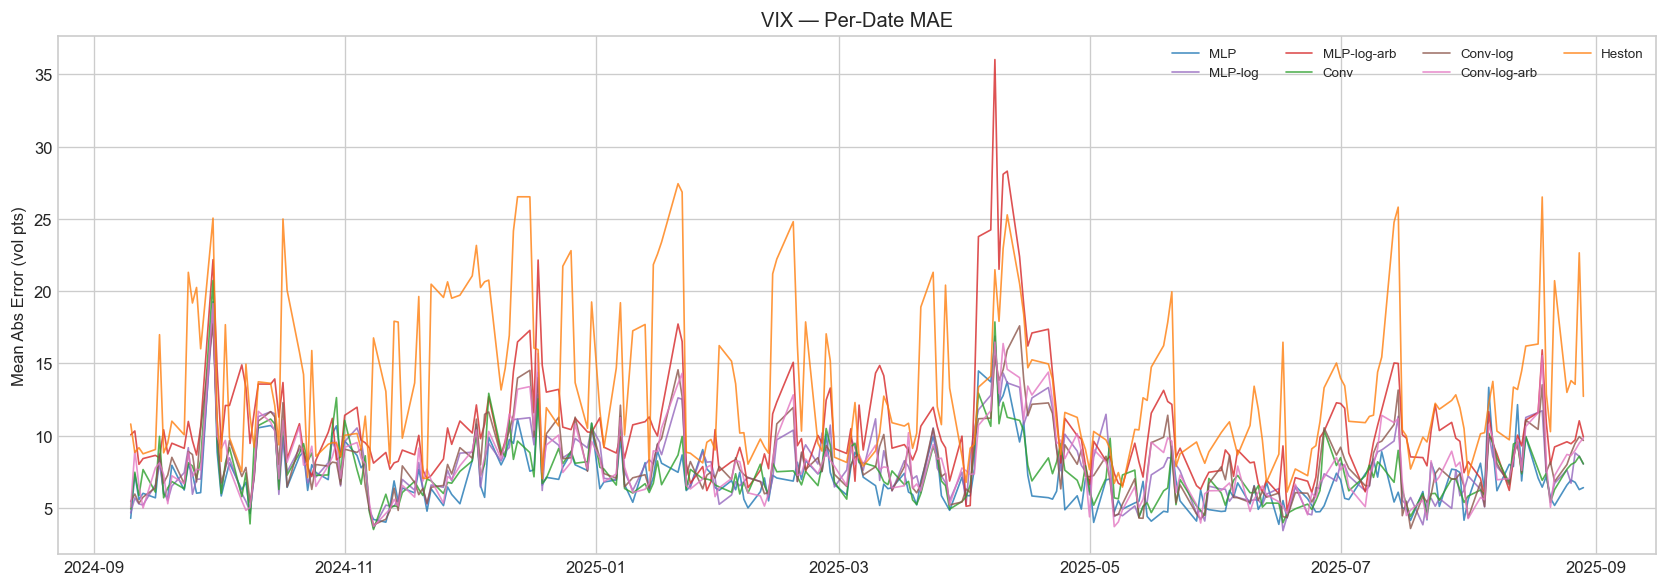

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
for name in MODEL_NAMES:
    date_mae = np.array([
        np.nanmean(np.abs(models[name][t][valid[t]] - market[t][valid[t]]))
        for t in range(N)
    ]) * 100
    ax.plot(aligned_dates, date_mae, color=COLOURS[name], label=name, alpha=0.8, lw=1)
ax.set_ylabel("Mean Abs Error (vol pts)")
ax.set_title(f"{TICKER} — Per-Date MAE")
ax.legend(fontsize=8, ncol=4)
fig.tight_layout()
fig.savefig(OUT / "plots" / "mae_timeseries.png", bbox_inches="tight", dpi=150)
plt.show()

## §5 Maturity & Delta Breakdown

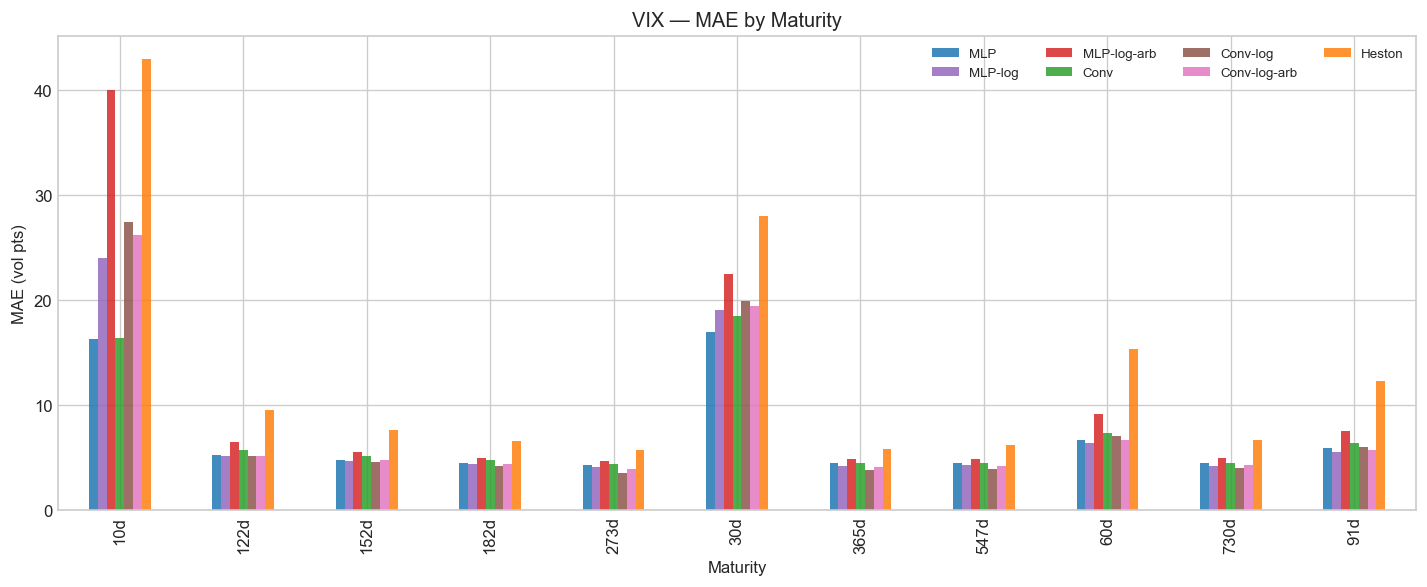

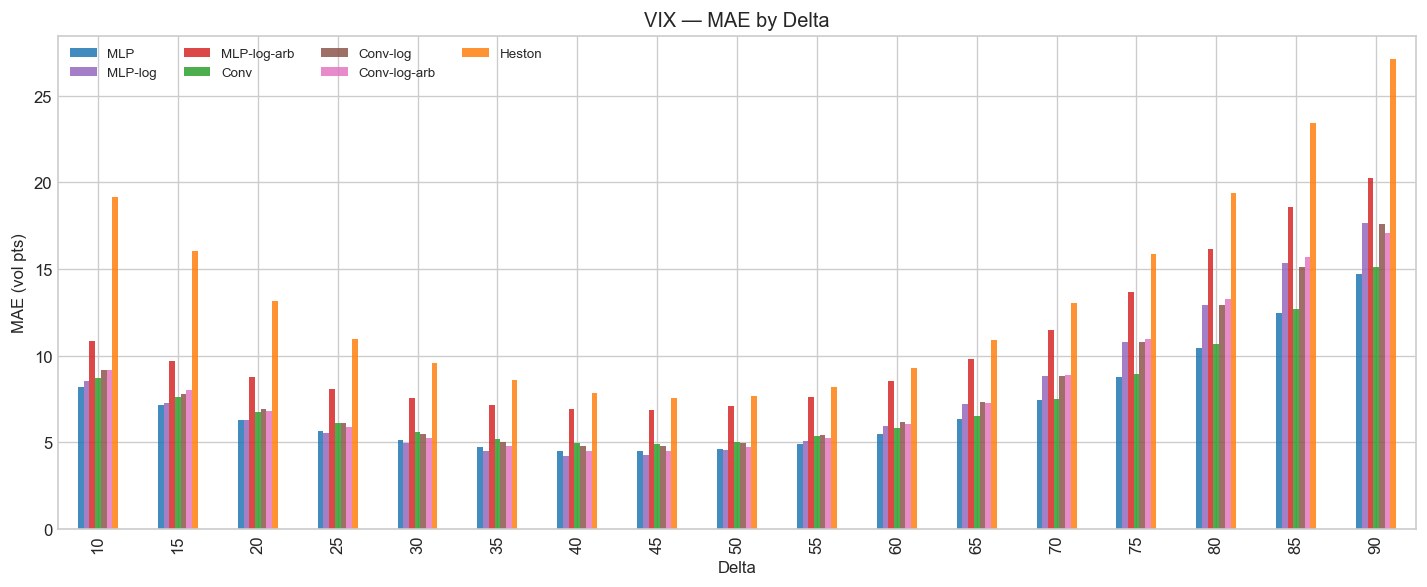

In [7]:
# MAE by maturity
mat_rows = []
for name in MODEL_NAMES:
    for h in range(n_mat):
        vm_h = valid[:, :, h, :]
        e_h = np.abs(models[name][:, :, h, :] - market[:, :, h, :])
        mat_rows.append({"Model": name, "Maturity": f"{days_grid[h]:.0f}d",
                        "MAE (vp)": np.nanmean(np.where(vm_h, e_h, np.nan))*100})

mat_df = pd.DataFrame(mat_rows).pivot(index="Maturity", columns="Model", values="MAE (vp)")
mat_df = mat_df[MODEL_NAMES]
mat_df.to_csv(OUT / "tables" / "mae_by_maturity.csv")

fig, ax = plt.subplots(figsize=(12, 5))
mat_df.plot(kind="bar", ax=ax, color=[COLOURS[n] for n in MODEL_NAMES], alpha=0.85)
ax.set_ylabel("MAE (vol pts)")
ax.set_title(f"{TICKER} — MAE by Maturity")
ax.legend(fontsize=8, ncol=4)
fig.tight_layout()
fig.savefig(OUT / "plots" / "mae_by_maturity.png", bbox_inches="tight", dpi=150)
plt.show()

# MAE by delta
del_rows = []
for name in MODEL_NAMES:
    for w in range(n_del):
        vm_w = valid[:, :, :, w]
        e_w = np.abs(models[name][:, :, :, w] - market[:, :, :, w])
        del_rows.append({"Model": name, "Delta": f"{delta_grid[w]*100:.0f}",
                        "MAE (vp)": np.nanmean(np.where(vm_w, e_w, np.nan))*100})

del_df = pd.DataFrame(del_rows).pivot(index="Delta", columns="Model", values="MAE (vp)")
del_df = del_df[MODEL_NAMES]
del_df.to_csv(OUT / "tables" / "mae_by_delta.csv")

fig, ax = plt.subplots(figsize=(12, 5))
del_df.plot(kind="bar", ax=ax, color=[COLOURS[n] for n in MODEL_NAMES], alpha=0.85)
ax.set_ylabel("MAE (vol pts)")
ax.set_title(f"{TICKER} — MAE by Delta")
ax.legend(fontsize=8, ncol=4)
fig.tight_layout()
fig.savefig(OUT / "plots" / "mae_by_delta.png", bbox_inches="tight", dpi=150)
plt.show()

## §6 Sample Surface Comparison

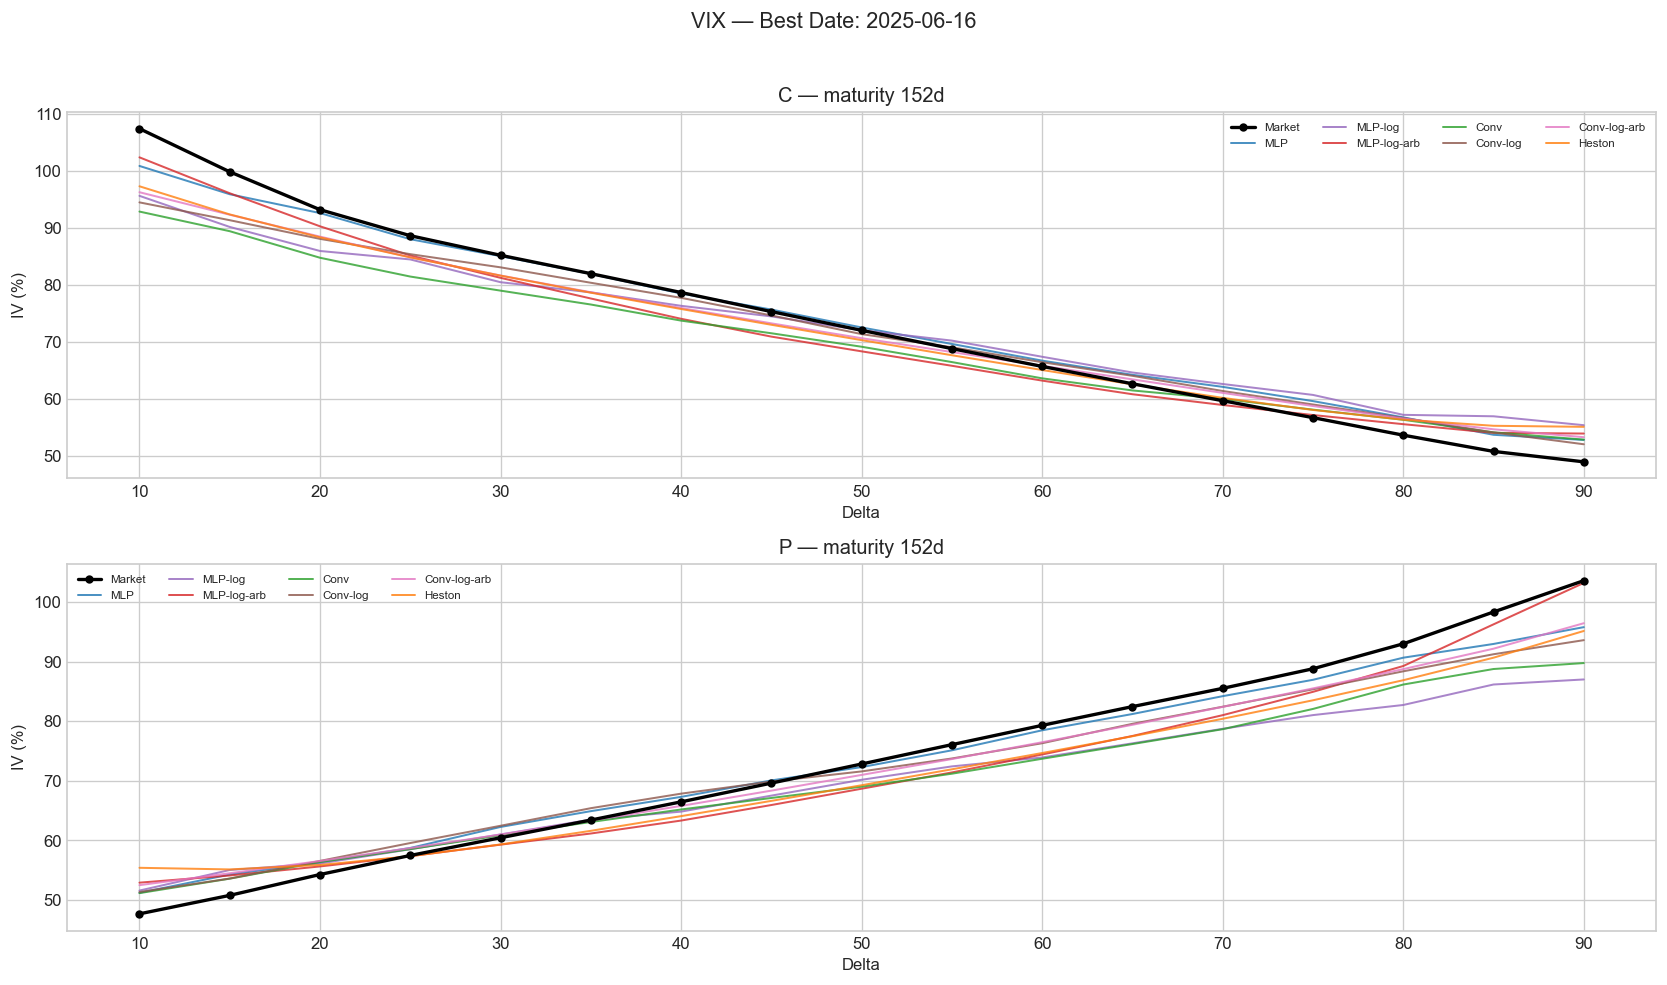

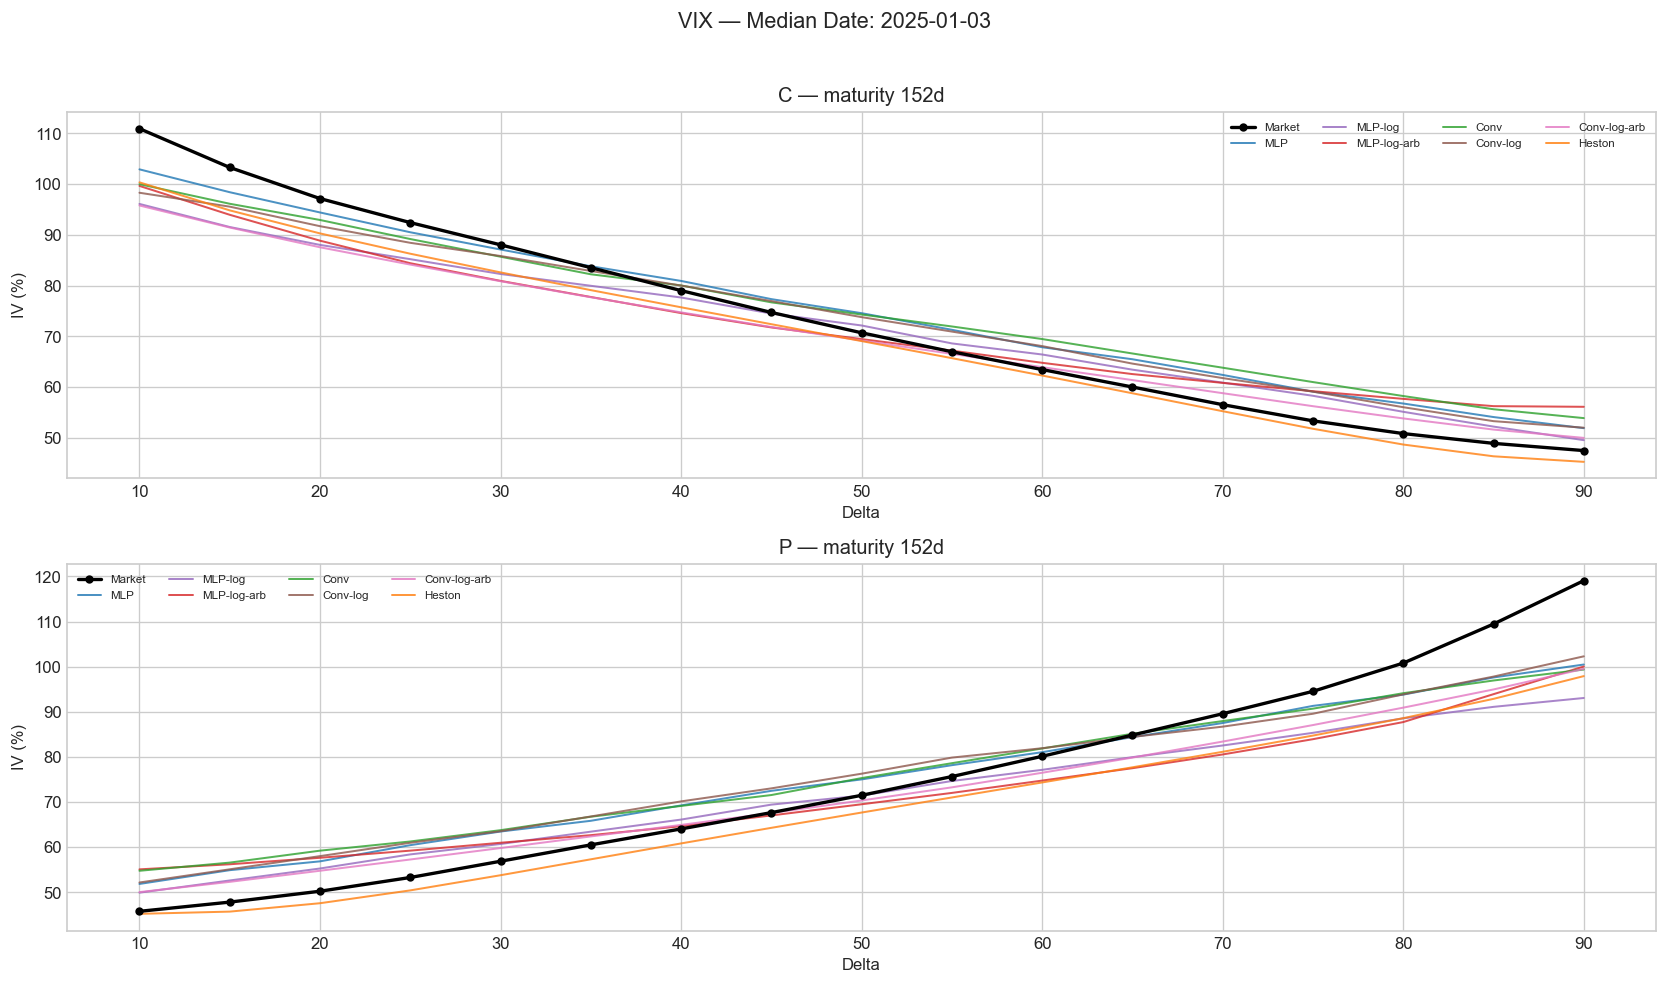

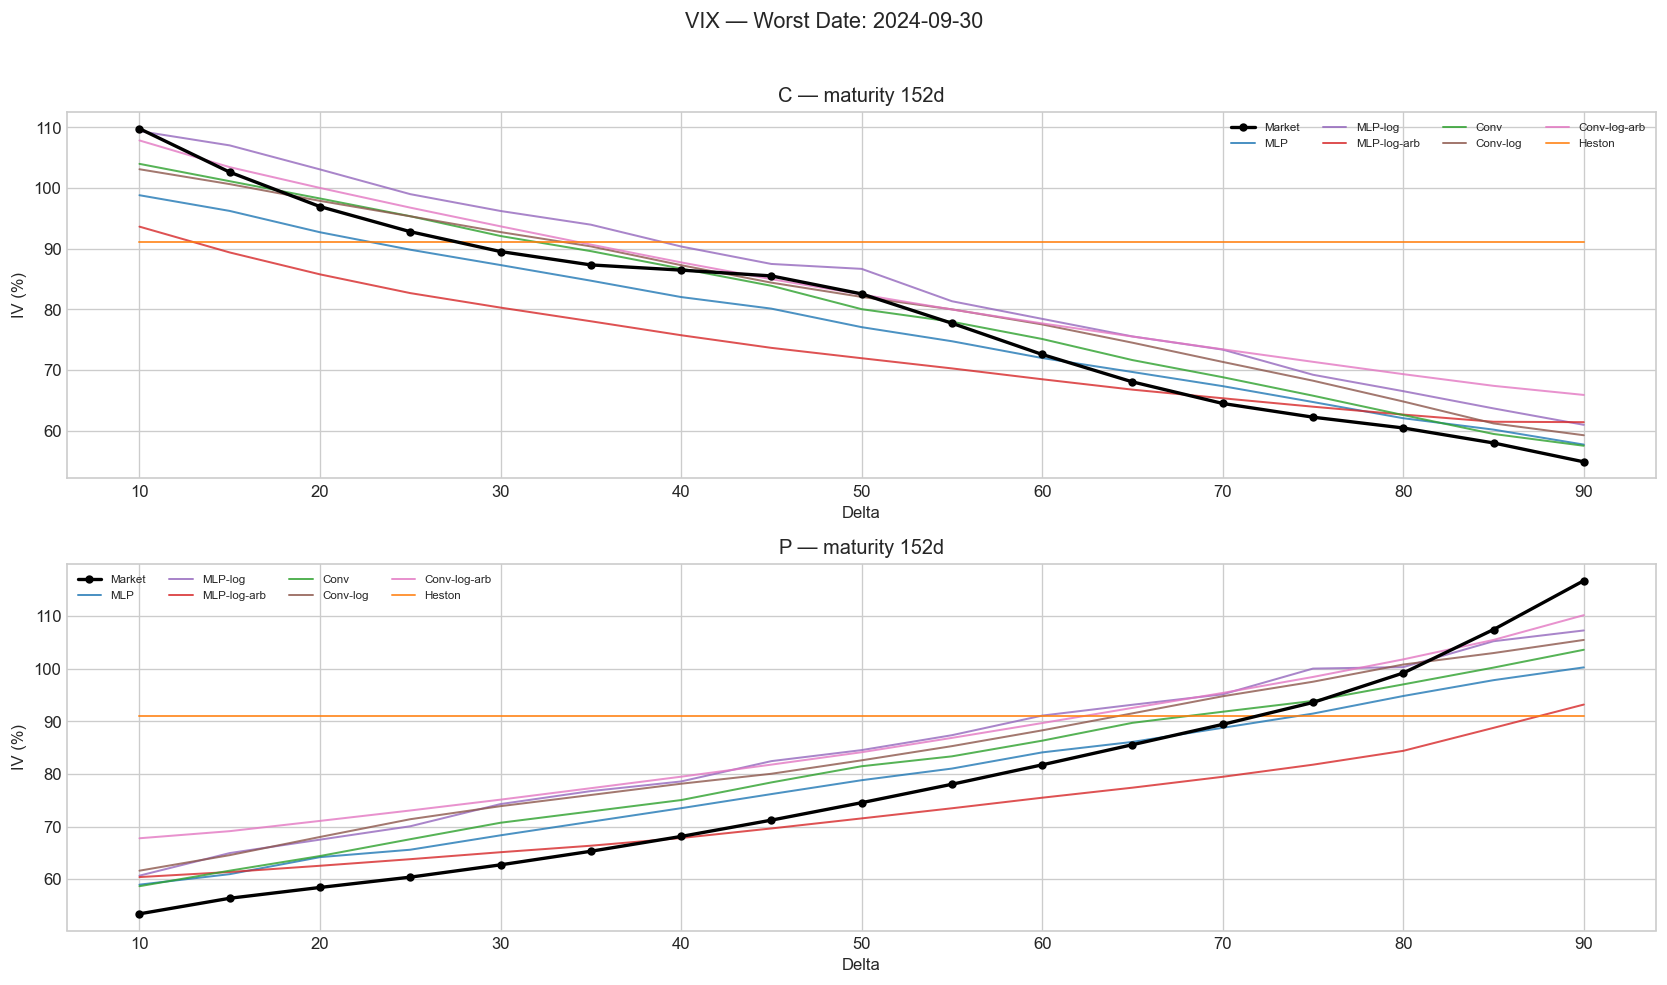

In [8]:
# Best / median / worst date by first VAE
first_vae_name = next(iter(vae_surfs))
date_mae_first = np.array([
    np.nanmean(np.abs(models[first_vae_name][t][valid[t]] - market[t][valid[t]]))
    for t in range(N)
])
sorted_idx = np.argsort(date_mae_first)
sample_indices = [sorted_idx[0], sorted_idx[N//2], sorted_idx[-1]]
sample_labels = ["Best", "Median", "Worst"]

for si, sl in zip(sample_indices, sample_labels):
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    for ch_idx, (ch_name, ax) in enumerate(zip(cp_labels, axes)):
        mid_mat = n_mat // 2
        market_slice = market[si, ch_idx, mid_mat, :] * 100
        ax.plot(delta_grid*100, market_slice, 'k-o', lw=2, ms=4, label="Market", zorder=10)
        for name in MODEL_NAMES:
            model_slice = models[name][si, ch_idx, mid_mat, :] * 100
            ax.plot(delta_grid*100, model_slice, color=COLOURS[name], label=name, alpha=0.8, lw=1.2)
        ax.set_xlabel("Delta")
        ax.set_ylabel("IV (%)")
        ax.set_title(f"{ch_name} — maturity {days_grid[mid_mat]:.0f}d")
        ax.legend(fontsize=7, ncol=4)
    date_str = str(aligned_dates.iloc[si].date()) if hasattr(aligned_dates.iloc[si], 'date') else str(aligned_dates.iloc[si])[:10]
    fig.suptitle(f"{TICKER} — {sl} Date: {date_str}", fontsize=13, y=1.02)
    fig.tight_layout()
    fig.savefig(OUT / "plots" / f"sample_{sl.lower()}.png", bbox_inches="tight", dpi=150)
    plt.show()

## §7 Per-Cell Win Count

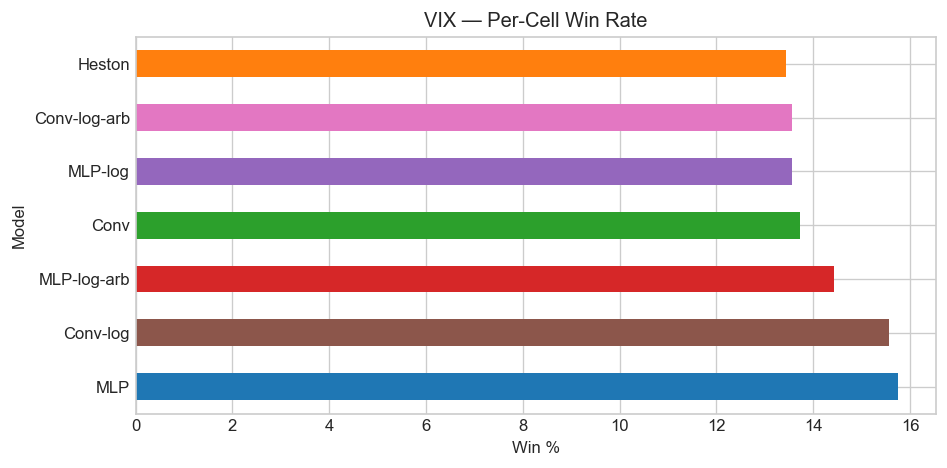

,Wins,Win %
Model,,
MLP,14297,15.75
Conv-log,14127,15.56
MLP-log-arb,13096,14.43
Conv,12457,13.72
MLP-log,12307,13.56
Conv-log-arb,12305,13.55
Heston,12193,13.43


In [9]:
win_counts = {name: 0 for name in MODEL_NAMES}
total_cells = 0
for t in range(N):
    for c in range(n_chan):
        for h in range(n_mat):
            for w in range(n_del):
                if not valid[t, c, h, w]:
                    continue
                total_cells += 1
                best_err = np.inf
                best_name = None
                for name in MODEL_NAMES:
                    ae = abs(models[name][t, c, h, w] - market[t, c, h, w])
                    if ae < best_err:
                        best_err = ae
                        best_name = name
                if best_name:
                    win_counts[best_name] += 1

win_df = pd.DataFrame([
    {"Model": name, "Wins": cnt, "Win %": 100*cnt/max(total_cells,1)}
    for name, cnt in win_counts.items()
]).set_index("Model").sort_values("Win %", ascending=False)
win_df.to_csv(OUT / "tables" / "per_cell_wins.csv")

fig, ax = plt.subplots(figsize=(8, 4))
colors = [COLOURS[n] for n in win_df.index]
win_df["Win %"].plot(kind="barh", ax=ax, color=colors)
ax.set_xlabel("Win %")
ax.set_title(f"{TICKER} — Per-Cell Win Rate")
fig.tight_layout()
fig.savefig(OUT / "plots" / "per_cell_wins.png", bbox_inches="tight", dpi=150)
plt.show()
display(win_df.round(2))

## Summary

All comparison artifacts saved to `artifacts/comparison/VIX/`.